In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/Cleaned_netflix_titles.csv")
df.head()

,Unnamed: 0,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,primary_genre
0,0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not-Mentioned,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,9,Documentaries
1,1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,9,International TV Shows
2,2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,9,Crime TV Shows
3,3,s4,TV Show,Jailbirds New Orleans,Unknown,Not-Mentioned,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021,9,Docuseries
4,4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021,9,International TV Shows


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8794 entries, 0 to 8793
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Unnamed: 0     8794 non-null   int64 
 1   show_id        8794 non-null   object
 2   type           8794 non-null   object
 3   title          8794 non-null   object
 4   director       8794 non-null   object
 5   cast           8794 non-null   object
 6   country        8792 non-null   object
 7   date_added     8794 non-null   object
 8   release_year   8794 non-null   int64 
 9   rating         8794 non-null   object
 10  duration       8794 non-null   object
 11  listed_in      8794 non-null   object
 12  description    8794 non-null   object
 13  year_added     8794 non-null   int64 
 14  month_added    8794 non-null   int64 
 15  primary_genre  8794 non-null   object
dtypes: int64(4), object(12)
memory usage: 1.1+ MB


In [6]:
df.describe()

,Unnamed: 0,release_year,year_added,month_added
count,8794.000000,8794.000000,8794.000000,8794.000000
mean,4399.527632,2014.183534,2018.872754,6.654878
std,2542.595372,8.823527,1.573789,3.436903
min,0.000000,1925.000000,2008.000000,1.000000
25%,2198.250000,2013.000000,2018.000000,4.000000
50%,4396.500000,2017.000000,2019.000000,7.000000
75%,6599.750000,2019.000000,2020.000000,10.000000
max,8806.000000,2021.000000,2021.000000,12.000000


In [7]:
df['type'].value_counts()

type
Movie      6128
TV Show    2666
Name: count, dtype: int64

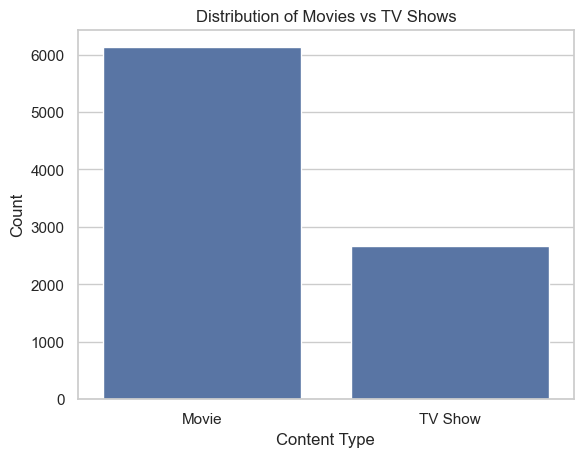

In [8]:
sns.countplot(data=df, x='type')
plt.title("Distribution of Movies vs TV Shows")
plt.xlabel("Content Type")
plt.ylabel("Count")
plt.show()

Insights: There are more no of Movies compared to TV Show's. This means Netflix prioritizes Movies rather than TV Shows.

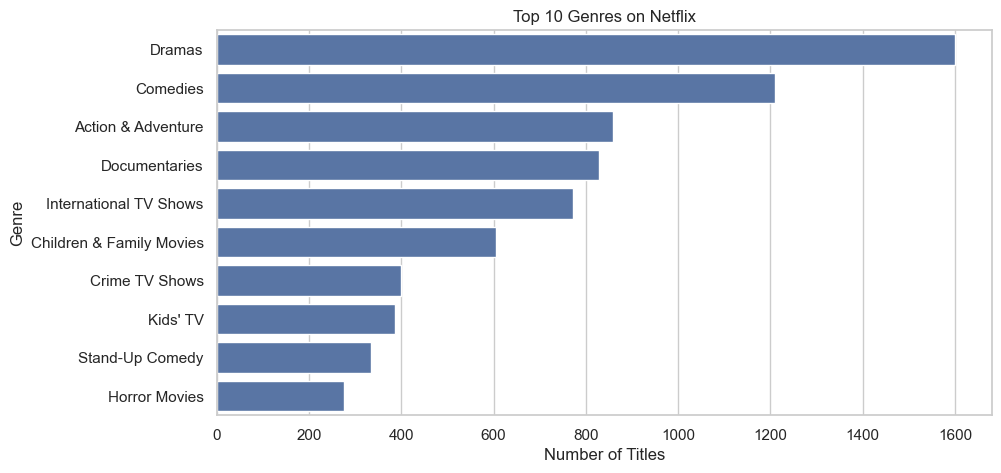

In [9]:
top_genres = df['primary_genre'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_genres.values, y=top_genres.index)
plt.title("Top 10 Genres on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")
plt.show()

Insights: Dramas and Comedies are most watched or top geners among the list followed by Action and adventure, documentaries all other categories. Horror Movies are the least geners on Netflix.

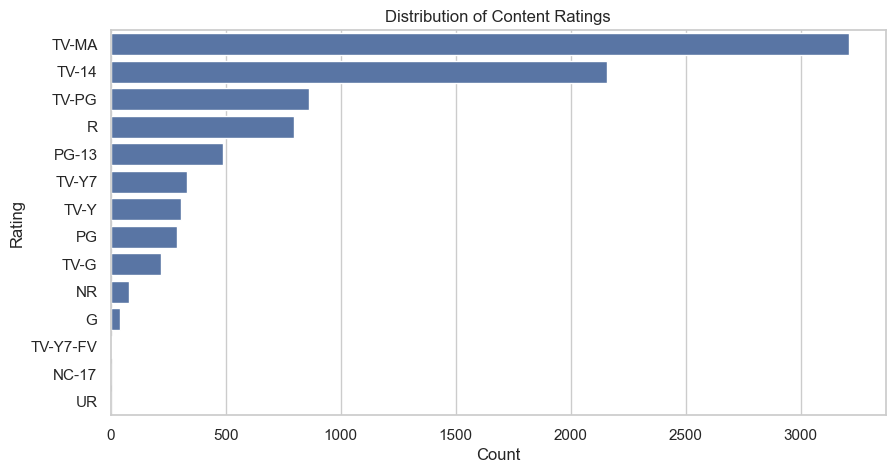

In [10]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, y='rating', order=df['rating'].value_counts().index)
plt.title("Distribution of Content Ratings")
plt.xlabel("Count")
plt.ylabel("Rating")
plt.show()

Insight: The majority of Netflix content falls under TV-MA and TV-14 ratings, indicating a strong focus on mature and teenage audiences. Family and children’s categories represent a smaller portion of the plot, suggesting Netflix prioritizes adult-oriented entertainment.

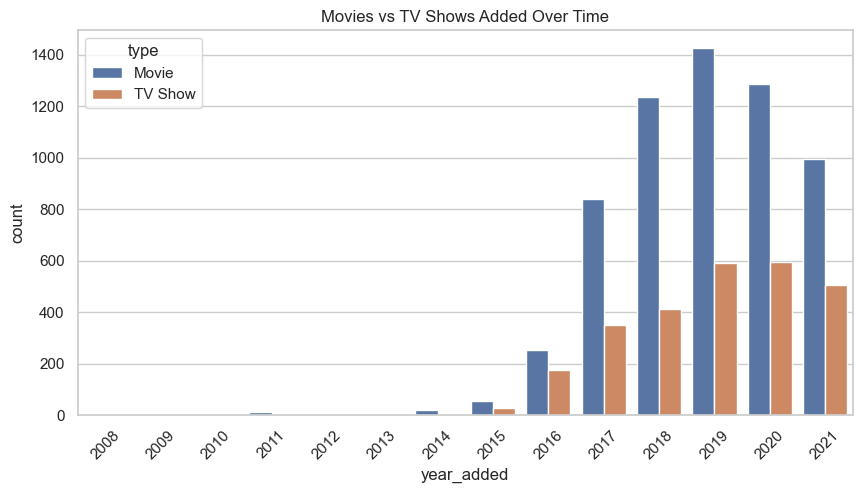

In [17]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='year_added', hue='type')
plt.xticks(rotation=45)
plt.title("Movies vs TV Shows Added Over Time")
plt.show()

Insight: Netflix experienced rapid content expansion starting in 2016, peaking around 2019. While both Movies and TV Shows increased significantly, Movies consistently outnumbered TV Shows, indicating a stronger emphasis on film content during expansion years.

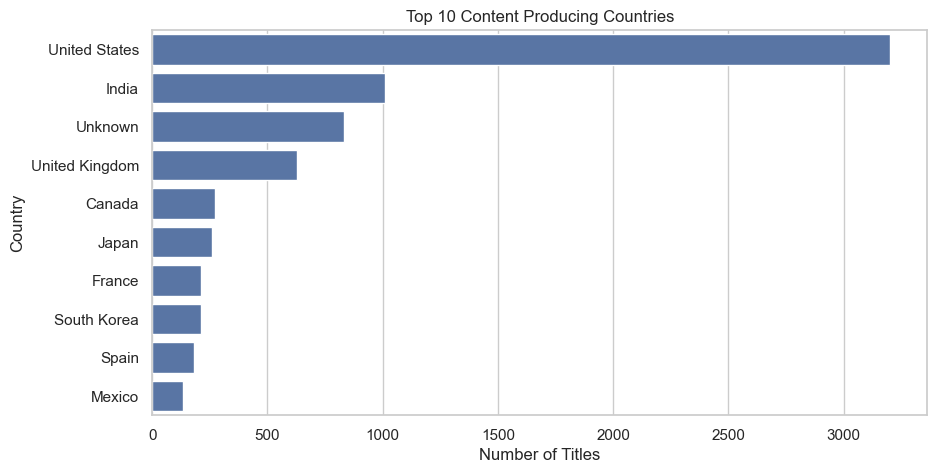

In [18]:
top_countries = df['country'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title("Top 10 Content Producing Countries")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.show()

Insight: The United States overwhelmingly dominates Netflix’s content library, contributing more than three times the volume of the second-highest country (India). This indicates Netflix’s strong dependence on US-produced content while gradually expanding international catalogs.

And also there is also signifiicant presence of "Unknown" which can cause geographical trend analysis.

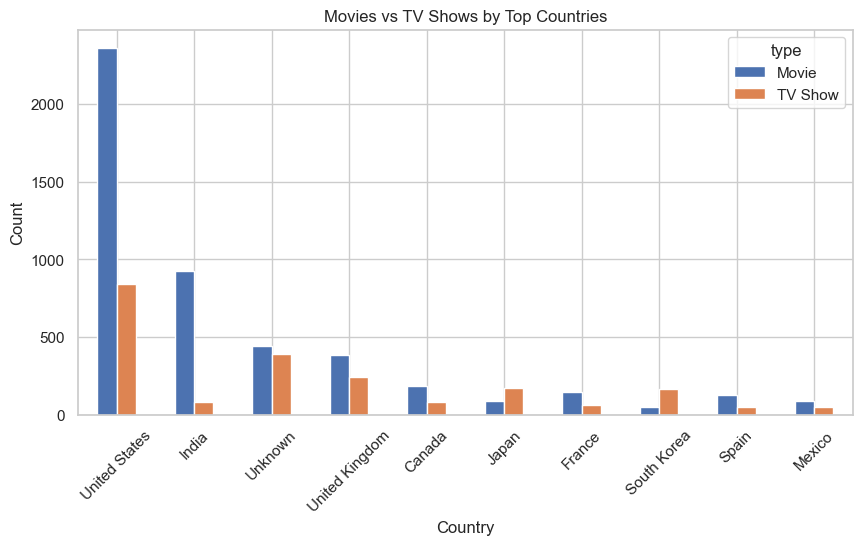

In [ ]:
country_type = pd.crosstab(df['country'], df['type'])
top_countries = df['country'].value_counts().head(10).index

country_type.loc[top_countries].plot(kind='bar', figsize=(10,5))
plt.title("Movies vs TV Shows by Top Countries")
plt.xlabel("Country")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

Insight: The United States and India primarily contribute movie content, whereas countries like South Korea and Japan show a relatively higher proportion of TV Shows. This suggests regional differences in content production strategies and audience preferences.

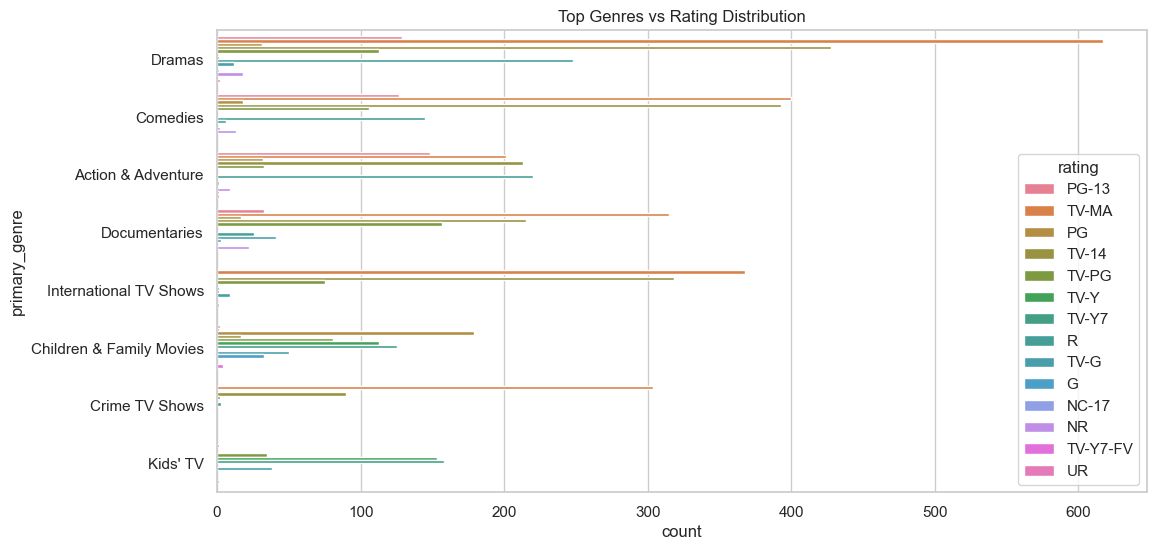

In [20]:
plt.figure(figsize=(12,6))
sns.countplot(data=df, y='primary_genre', hue='rating',
              order=df['primary_genre'].value_counts().head(8).index)
plt.title("Top Genres vs Rating Distribution")
plt.show()

Insight: Mature ratings (TV-MA and TV-14) dominate across most major genres, particularly Dramas and Comedies, indicating Netflix’s strategic focus on adult and young adult audiences. In contrast, Children & Family genres are primarily aligned with kid-friendly ratings such as TV-Y and TV-G, reflecting clear audience segmentation.

In [22]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description',
       'year_added', 'month_added', 'primary_genre'],
      dtype='object')

In [23]:
df['duration_num'] = df['duration'].str.extract('(\d+)').astype(int)

<>:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\Jalaluddin Pathan\AppData\Local\Temp\ipykernel_10116\1891223089.py:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  df['duration_num'] = df['duration'].str.extract('(\d+)').astype(int)


In [24]:
df[['duration', 'duration_num']].head()

,duration,duration_num
0,90 min,90
1,2 Seasons,2
2,1 Season,1
3,1 Season,1
4,2 Seasons,2


In [27]:
df['length_category'] = None

# For Movies → categorize by minutes
df.loc[df['type'] == 'Movie', 'length_category'] = pd.cut(
    df.loc[df['type'] == 'Movie', 'duration_num'],
    bins=[0, 60, 120, 1000],
    labels=["Short", "Medium", "Long"]
)

# For TV Shows → categorize by seasons
df.loc[df['type'] == 'TV Show', 'length_category'] = pd.cut(
    df.loc[df['type'] == 'TV Show', 'duration_num'],
    bins=[0, 1, 3, 50],
    labels=["Single Season", "Few Seasons", "Many Seasons"]
)

In [28]:
df['length_category'].value_counts()

length_category
Medium           4499
Single Season    1793
Long             1142
Few Seasons       619
Short             487
Many Seasons      254
Name: count, dtype: int64

In [29]:
pd.crosstab(df['type'], df['length_category'])

length_category,Few Seasons,Long,Many Seasons,Medium,Short,Single Season
type,,,,,,
Movie,0,1142,0,4499,487,0
TV Show,619,0,254,0,0,1793


In [ ]:
df['length_category'].isna().sum()

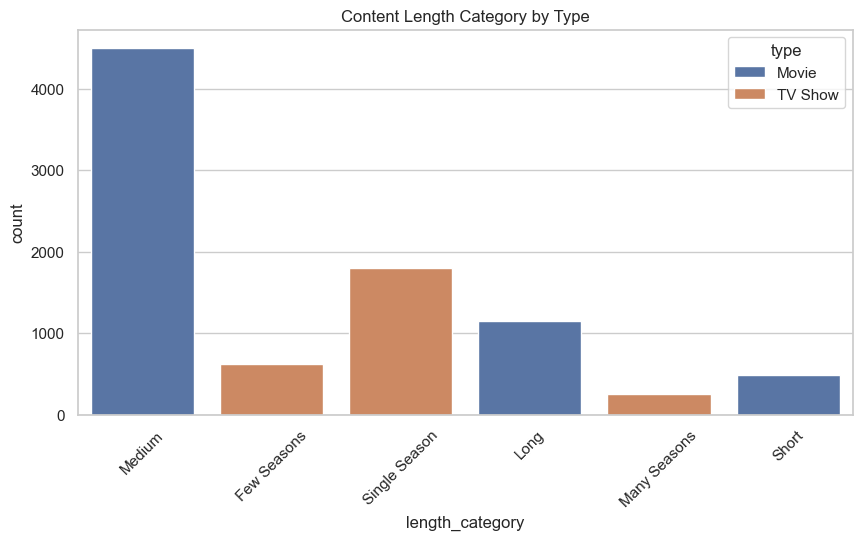

In [31]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='length_category', hue='type')
plt.xticks(rotation=45)
plt.title("Content Length Category by Type")
plt.show()

Insight: Most movies on Netflix fall within the medium-length category (60–120 minutes), indicating standard theatrical-style durations. In contrast, TV Shows are predominantly single-season series, with relatively fewer long-running multi-season productions.